In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import os

#raw_dataloader, plot_order_book, 

In [26]:
def raw_dataloader(version, round_num, start_day, end_day, trade_feed = False):
    """
    IMC Prosperity 데이터를 로드하고, 날짜별로 timestamp를 연속적으로 수정하여 합치는 함수
    
    :param version: 대회 버전 (예: 3, 4)
    :param round_num: 라운드 번호 (예: 0, 1)
    :param start_day: 시작 날짜 (예: -2)
    :param end_day: 종료 날짜 (예: -1)
    :param trade_feed: trade_feed를 쓸지 (예: False)
    :return: timestamp가 조정된 통합 DataFrame
    """
    df_list = []

    path = f"./{version}/round{round_num}/"
    
    for day in range(start_day, end_day + 1):
        file_name = f"prices_round_{round_num}_day_{day}.csv"
        if trade_feed:
            file_name = f"trades_round_{round_num}_day_{day}.csv"
        full_path = os.path.join(path, file_name)
        
        if os.path.exists(full_path):
            # 1. 파일 읽기 (구분자는 세미콜론)
            df = pd.read_csv(full_path, sep=';')
            
            # 2. Timestamp 조정
            # (현재날짜 - 시작날짜) * 1,000,000 을 더해 시간이 이어지게 만듦
            day_offset = (day - start_day) * 1000000
            df['timestamp'] = df['timestamp'] + day_offset
            df_list.append(df)
        else:
            print(f"파일을 찾을 수 없습니다: {full_path}")
            
    # 3. 데이터 합치기
    if df_list:
        # 멀티인덱스 없이 단순히 위아래로 합침
        combined_df = pd.concat(df_list, axis=0, ignore_index=True)
        
        # 전체 데이터 정렬 (시간순)
        combined_df = combined_df.sort_values('timestamp').reset_index(drop=True)
        return combined_df
    else:
        print("데이터를 불러오지 못했습니다.")
        return None



In [28]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_order_book(book_df, trade_df, target_product, start_ts, end_ts, target_day=None):
    """
    특정 상품, 타임스탬프 구간의 오더북 변화와 체결 내역을 시각화합니다. (점 그래프)
    """
    # 1. Book 데이터 필터링 및 정렬
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)

    book_filtered = book_df[book_cond].copy()
    book_filtered.sort_values('timestamp', inplace=True) # 타임스탬프 기준 정렬

    if book_filtered.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 2. Trade 데이터 필터링 및 정렬
    symbol_col = 'symbol' if 'symbol' in trade_df.columns else 'product'
    trade_cond = (trade_df[symbol_col] == target_product) & \
                 (trade_df['timestamp'] >= start_ts) & \
                 (trade_df['timestamp'] <= end_ts)
        
    trade_filtered = trade_df[trade_cond].copy()
    
    # 3. 그래프 그리기
    fig, ax = plt.subplots(figsize=(15, 8))

    # 호가 점의 기본 크기 설정
    dot_size = 70

    # Ask (매도 호가) - 빨간색 계열 (선에서 점으로 변경)
    if 'ask_price_3' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_3'], color='salmon', alpha=0.3, s=dot_size)
    if 'ask_price_2' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_2'], color='red', alpha=0.5, s=dot_size)
    ax.scatter(book_filtered['timestamp'], book_filtered['ask_price_1'], color='darkred', alpha=1.0, label='Ask 1', s=dot_size)

    # Bid (매수 호가) - 파란색 계열 (선에서 점으로 변경)
    ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_1'], color='darkblue', alpha=1.0, label='Bid 1', s=dot_size)
    if 'bid_price_2' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_2'], color='blue', alpha=0.5, s=dot_size)
    if 'bid_price_3' in book_filtered.columns:
        ax.scatter(book_filtered['timestamp'], book_filtered['bid_price_3'], color='cornflowerblue', alpha=0.3, s=dot_size)

    # 4. 체결 내역(Trade) 마킹하기 (별표 유지)
    if not trade_filtered.empty:
        # 거래량(quantity)에 따라 마커 크기 조정 (기본 크기 50 + 거래량 * 10)
        sizes = 50 + (trade_filtered['quantity'] * 10) if 'quantity' in trade_filtered.columns else 100
        
        ax.scatter(trade_filtered['timestamp'], trade_filtered['price'],
                   color='gold', marker='*', s=sizes, label='Trade', zorder=5, edgecolor='black', linewidth=0.5)

    # 디자인 및 축 설정
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax.set_title(f"Microstructure: {target_product} ({day_str}{start_ts} ~ {end_ts})", fontsize=16)
    ax.set_xlabel("Timestamp", fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # x축의 숫자 포맷이 지수 형태(1e6 등)로 나오는 것을 방지
    ax.ticklabel_format(style='plain', axis='x')
    
    plt.tight_layout()
    plt.show()

In [126]:
import numpy as np
def wall_mid_pq(book_df, trade_df):
    # ==========================================
    # 1. book_df에 Wall Mid 추가
    # ==========================================
    # 결측치(NaN)는 -1로 채워 연산 오류를 방지하고 가장 물량이 적은 것으로 처리합니다.
    bid_vols = book_df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].fillna(-1)
    bid_prices = book_df[['bid_price_1', 'bid_price_2', 'bid_price_3']]
    
    ask_vols = book_df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].fillna(-1)
    ask_prices = book_df[['ask_price_1', 'ask_price_2', 'ask_price_3']]
    
    # 행별로 물량(Volume)이 가장 큰 호가의 인덱스(0, 1, 2)를 찾음
    max_bid_idx = bid_vols.values.argmax(axis=1)
    max_ask_idx = ask_vols.values.argmax(axis=1)
    
    # 해당 인덱스에 매칭되는 실제 가격(Wall Price)을 추출
    bid_walls = np.take_along_axis(bid_prices.values, max_bid_idx[:, None], axis=1).flatten()
    ask_walls = np.take_along_axis(ask_prices.values, max_ask_idx[:, None], axis=1).flatten()
    
    # Wall Mid 계산
    book_df['wall_mid'] = (bid_walls + ask_walls) / 2
    
    # ==========================================
    # 2. book_df에 pq (Price * Quantity) 추가
    # ==========================================
    # 예시로 1호가에 대해서만 계산했습니다. (필요 시 2, 3호가로 확장 가능)
    book_df['bid_pq_1'] = book_df['bid_price_1'] * book_df['bid_volume_1']
    book_df['ask_pq_1'] = book_df['ask_price_1'] * book_df['ask_volume_1']
    
    # ==========================================
    # 3. trade_df에 pq 추가
    # ==========================================
    trade_df['pq'] = trade_df['price'] * trade_df['quantity']
    return book_df, trade_df

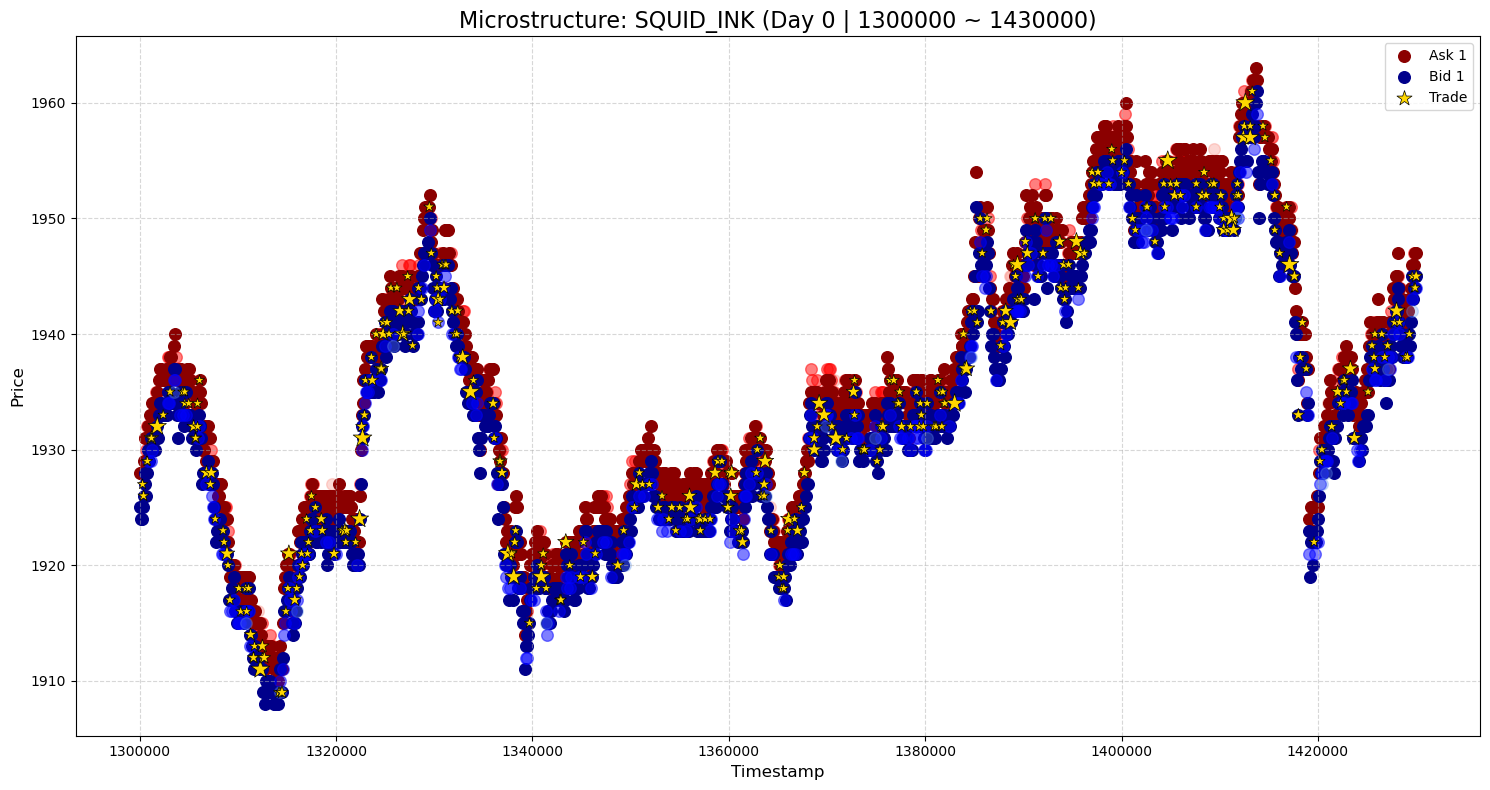

In [128]:
book_df = raw_dataloader(version=3, round_num=2, start_day=-1, end_day=0, trade_feed=False)
trade_df = raw_dataloader(version=3, round_num=2, start_day=-1, end_day=0, trade_feed=True)
wall_mid_pq(book_df, trade_df)

plot_order_book(book_df, trade_df, target_product='SQUID_INK', target_day=0, start_ts=1300000, end_ts=1430000)

In [74]:
whole_product = set(book_df['product'])
whole_product

{'CROISSANTS',
 'DJEMBES',
 'JAMS',
 'KELP',
 'PICNIC_BASKET1',
 'PICNIC_BASKET2',
 'RAINFOREST_RESIN',
 'SQUID_INK'}

NameError: name 'SQUID_INK' is not defined

In [100]:
trade_df[trade_df['timestamp']==100]

,timestamp,buyer,seller,symbol,currency,price,quantity
4,100,NaN,NaN,CROISSANTS,SEASHELLS,4304.0,6


In [50]:
book_df[book_df['product'] == 'SQUID_INK']

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
6,1,0,SQUID_INK,1834.0,23.0,NaN,NaN,NaN,NaN,1838,23,NaN,NaN,NaN,NaN,1836.0,0.0
22,1,100,SQUID_INK,1838.0,1.0,1837.0,2.0,1836.0,22.0,1839,22,NaN,NaN,NaN,NaN,1838.5,0.0
40,1,200,SQUID_INK,1839.0,22.0,NaN,NaN,NaN,NaN,1842,22,NaN,NaN,NaN,NaN,1840.5,0.0
49,1,300,SQUID_INK,1843.0,1.0,1841.0,26.0,NaN,NaN,1844,26,NaN,NaN,NaN,NaN,1843.5,0.0
73,1,400,SQUID_INK,1842.0,28.0,NaN,NaN,NaN,NaN,1845,28,NaN,NaN,NaN,NaN,1843.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149926,1,999500,SQUID_INK,1878.0,1.0,1876.0,25.0,NaN,NaN,1879,25,NaN,NaN,NaN,NaN,1878.5,0.0
149951,1,999600,SQUID_INK,1879.0,2.0,1878.0,24.0,NaN,NaN,1881,24,NaN,NaN,NaN,NaN,1880.0,0.0
149960,1,999700,SQUID_INK,1878.0,30.0,NaN,NaN,NaN,NaN,1879,1,1882.0,30.0,NaN,NaN,1878.5,0.0
149970,1,999800,SQUID_INK,1881.0,24.0,NaN,NaN,NaN,NaN,1883,8,1884.0,24.0,NaN,NaN,1882.0,0.0


(array([  4.,  36.,  60.,   9.,  19.,  66.,  30., 190., 177., 112.,  30.,
         75.,  26.,   4.,   8.,   3.,   5.,   0.,   3.,   4.,   0.,   3.,
          9.,  14.,  19., 101., 127.,  41., 250., 291., 200.,  39., 101.,
         69.,  27., 127., 119.,  39., 181., 129., 160.,  51., 288., 140.,
         45., 326., 352., 555., 106., 410., 445., 107., 440., 326., 489.,
         92., 305., 473.,  89., 587., 426., 513., 113., 623., 620., 135.,
        627., 503., 118., 447., 349., 824., 132., 803., 661., 144., 836.,
        457., 943., 141., 454., 207.,  60., 170., 164., 189.,  28., 105.,
        178.,  27., 114.,  77.,  69.,   3.,  33.,  55.,  13.,  71.,  32.,
          3.]),
 array([4269.5 , 4270.21, 4270.92, 4271.63, 4272.34, 4273.05, 4273.76,
        4274.47, 4275.18, 4275.89, 4276.6 , 4277.31, 4278.02, 4278.73,
        4279.44, 4280.15, 4280.86, 4281.57, 4282.28, 4282.99, 4283.7 ,
        4284.41, 4285.12, 4285.83, 4286.54, 4287.25, 4287.96, 4288.67,
        4289.38, 4290.09, 4290.8 ,

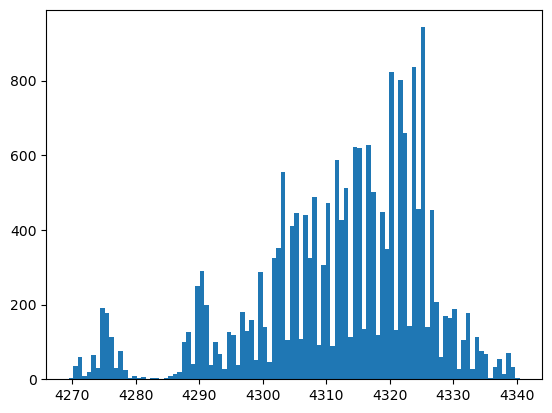

In [76]:
#SQUID_INK
#KELP
product = "CROISSANTS"
plt.hist(book_df[book_df['product']==product]['mid_price'], bins=100)

(array([ 17.,  25.,   8.,  29.,  18.,  25.,  77.,  38.,  27.,  70., 112.,
         47.,  68., 196.,  83.,  83., 160.,  60.,  99.,  67., 105.,  83.,
         67., 117., 103., 113., 206., 107., 111., 113., 183., 102., 128.,
        255., 186., 132., 205., 138., 145., 129., 503., 309., 292., 599.,
        359., 430., 764., 348., 387., 437., 943., 427., 435., 729., 254.,
        194., 300., 146., 142., 119., 220., 122., 101., 187., 109., 105.,
        208., 128., 150., 193., 413., 236., 287., 436., 194., 267., 534.,
        308., 238., 280., 484., 224., 226., 366., 193., 239., 325., 156.,
        157., 125., 305.,  78.,  43.,  69.,  39.,  22.,  67.,   3.,   5.,
          4.]),
 array([13389. , 13390.3, 13391.6, 13392.9, 13394.2, 13395.5, 13396.8,
        13398.1, 13399.4, 13400.7, 13402. , 13403.3, 13404.6, 13405.9,
        13407.2, 13408.5, 13409.8, 13411.1, 13412.4, 13413.7, 13415. ,
        13416.3, 13417.6, 13418.9, 13420.2, 13421.5, 13422.8, 13424.1,
        13425.4, 13426.7, 13428. ,

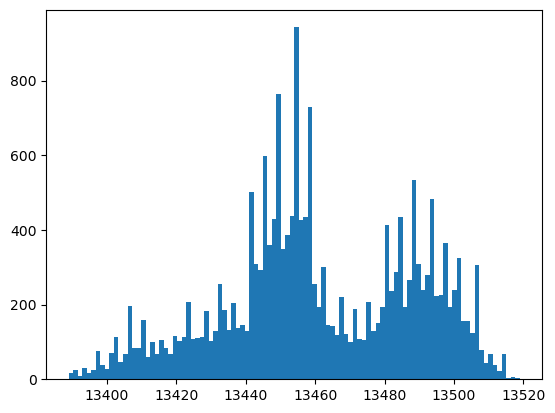

In [78]:
product = "DJEMBES"
plt.hist(book_df[book_df['product']==product]['bid_price_1'], bins=100)

In [136]:
import matplotlib.pyplot as plt
import pandas as pd

def visualize_trade_pattern(book_df, trade_df, target_product, target_quantity=None, target_buyer=None, target_seller=None):
    """
    특정 상품의 가격 흐름과 조건에 맞는 거래 내역을 시각화합니다.
    """
    # 1. 오더북 데이터 필터링 (배경 가격 선)
    book_subset = book_df[book_df['product'] == target_product].copy()
    book_subset = book_subset.sort_values('timestamp')
    
    # 2. 체결 데이터 필터링 (마커로 표시할 거래)
    trade_subset = trade_df[trade_df['symbol'] == target_product].copy()
    
    # 수량 조건 필터링
    if target_quantity is not None:
        trade_subset = trade_subset[trade_subset['quantity'] == target_quantity]
        
    # 구매자/판매자 조건 필터링 (익명 거래를 찾을 때 유용함, 예: isna() 조건 등)
    if target_buyer is not None:
        # 익명(NaN)인 경우를 필터링하고 싶다면 target_buyer를 'anonymous'로 넘겨서 처리
        if target_buyer == 'anonymous':
            trade_subset = trade_subset[trade_subset['buyer'].isna()]
        else:
            trade_subset = trade_subset[trade_subset['buyer'] == target_buyer]
            
    if target_seller is not None:
        if target_seller == 'anonymous':
            trade_subset = trade_subset[trade_subset['seller'].isna()]
        else:
            trade_subset = trade_subset[trade_subset['seller'] == target_seller]

    # 3. 그래프 그리기
    plt.figure(figsize=(15, 7))
    
    # 파란색 선: 1호가 매수 잔량 가격 (Bid)
    plt.plot(book_subset['timestamp'], book_subset['bid_price_1'], 
             color='blue', linewidth=1, alpha=0.7, label='Bid Price 1')
    
    # 빨간색 선: 1호가 매도 잔량 가격 (Ask)
    plt.plot(book_subset['timestamp'], book_subset['ask_price_1'], 
             color='red', linewidth=1, alpha=0.7, label='Ask Price 1')
    
    # 보라색 마커: 필터링된 특정 거래 시점 표시
    # 이미지와 비슷한 모래시계/삼각형 느낌을 내기 위해 큰 마커 사용
    if not trade_subset.empty:
        plt.scatter(trade_subset['timestamp'], trade_subset['price'], 
                    color='darkviolet', marker='v', s=150, zorder=5, 
                    label=f'Target Trades (Qty={target_quantity})')
        plt.scatter(trade_subset['timestamp'], trade_subset['price'], 
                    color='darkviolet', marker='^', s=150, zorder=5) # 겹쳐서 모래시계 모양 만들기
        
        # 최저점/최고점에 동그라미 표시 (선택 사항)
        min_trade = trade_subset.loc[trade_subset['price'].idxmin()]
        max_trade = trade_subset.loc[trade_subset['price'].idxmax()]
        
        plt.scatter(min_trade['timestamp'], min_trade['price'], 
                    facecolors='none', edgecolors='black', s=500, linewidth=2, zorder=6)
        plt.scatter(max_trade['timestamp'], max_trade['price'], 
                    facecolors='none', edgecolors='black', s=500, linewidth=2, zorder=6)

    # 4. 그래프 꾸미기
    plt.title(f'Trade Pattern Analysis: {target_product}', fontsize=16)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 배경색을 살짝 어둡게 (이미지와 비슷한 테마)
    plt.gca().set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 실행 예시 (올려주신 스크린샷 상황 재현)
# ==========================================
# SQUID_INK 상품 중, 거래량이 정확히 15이고, 익명(buyer/seller가 NaN)인 거래를 찾을 때:
# visualize_trade_pattern(book_df, trade_df, 
#                         target_product='SQUID_INK', 
#                         target_quantity=15, 
#                         target_buyer='anonymous', 
#                         target_seller='anonymous')

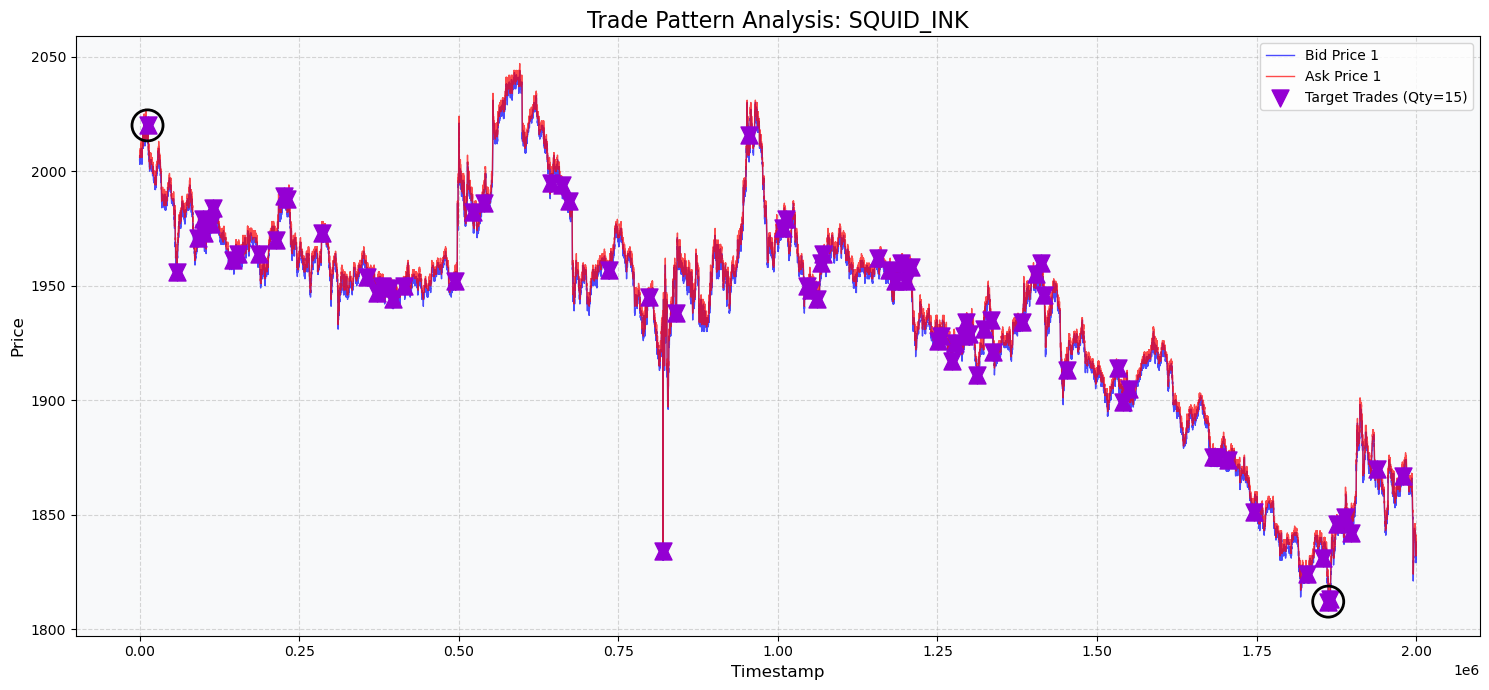

In [146]:
visualize_trade_pattern(book_df, trade_df, 
                         target_product='SQUID_INK', 
                         target_quantity=15, 
                         target_buyer='anonymous', 
                         target_seller='anonymous')

In [269]:
#14100로 확인가능

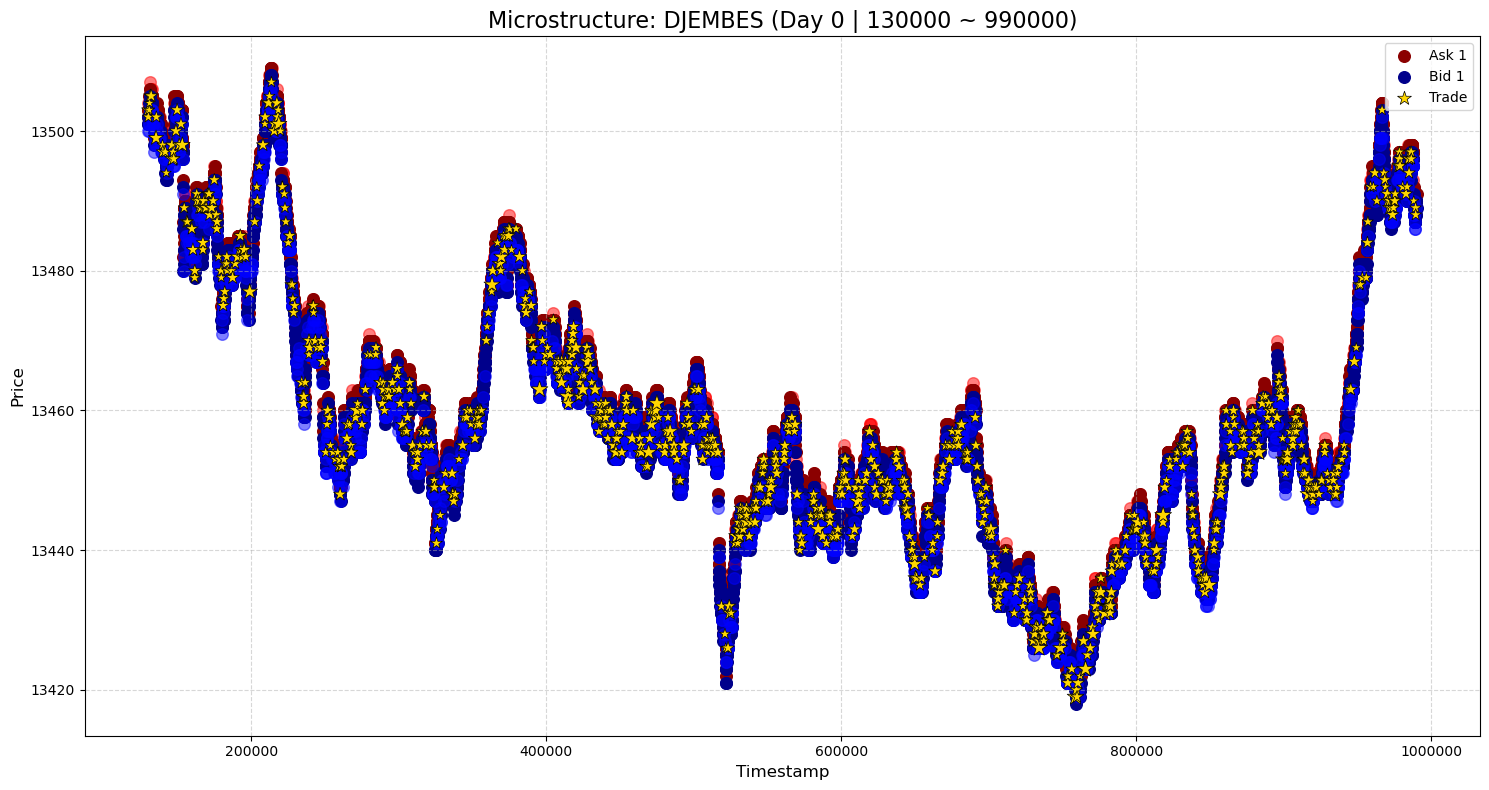

In [90]:
plot_order_book(book_df, trade_df, target_product='DJEMBES', target_day=0, start_ts=130000, end_ts=990000)

In [186]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_spread_and_trade(book_df, trade_df, target_product, start_ts, end_ts, target_day=None):
    """
    위: 가격과 체결 (Price & Trade) - 점 그래프
    아래: 스프레드와 체결 시점 (Spread & Trade Timing) - 점 그래프
    """
    # 1. Book 데이터 필터링 및 Spread 계산
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)

    book_filtered = book_df[book_cond].copy()
    book_filtered.sort_values('timestamp', inplace=True)
    
    # Spread (Ask 1 - Bid 1) 계산
    if not book_filtered.empty:
        book_filtered['spread'] = book_filtered['ask_price_1'] - book_filtered['bid_price_1']

    # 2. Trade 데이터 필터링
    symbol_col = 'symbol' if 'symbol' in trade_df.columns else 'product'
    trade_cond = (trade_df[symbol_col] == target_product) & \
                 (trade_df['timestamp'] >= start_ts) & \
                 (trade_df['timestamp'] <= end_ts)
        
    trade_filtered = trade_df[trade_cond].copy()

    if book_filtered.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 3. 그래프 그리기 (위/아래 2개 패널)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # 점의 기본 크기 설정
    dot_size = 80

    # --- [상단 패널] 오더북 Price & Trade ---
    # 선(step)을 점(scatter)으로 변경
    ax1.scatter(book_filtered['timestamp'], book_filtered['ask_price_1'], color='darkred', label='Ask 1', s=dot_size)
    ax1.scatter(book_filtered['timestamp'], book_filtered['bid_price_1'], color='darkblue', label='Bid 1', s=dot_size)
    
    if not trade_filtered.empty:
        # 거래량에 비례하여 마커 크기 설정 (별표 크기도 비율에 맞게 조정)
        sizes = 150 + (trade_filtered['quantity'] * 20) if 'quantity' in trade_filtered.columns else 200
        ax1.scatter(trade_filtered['timestamp'], trade_filtered['price'],
                   color='gold', marker='*', s=sizes, label='Trade', zorder=5, edgecolor='black', linewidth=0.5)
    
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax1.set_title(f"Spread & Trade Analysis: {target_product} ({day_str}{start_ts} ~ {end_ts})", fontsize=16)
    ax1.set_ylabel("Price", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- [하단 패널] Spread & Trade Timing ---
    # 선(step)을 점(scatter)으로 변경
    ax2.scatter(book_filtered['timestamp'], book_filtered['spread'], color='purple', label='Spread (Ask1 - Bid1)', s=dot_size)
    
    # 체결(Trade)이 발생한 시점을 수직선으로 표시하여 스프레드와의 관계 확인
    if not trade_filtered.empty:
        for _, row in trade_filtered.iterrows():
            # 거래량에 따라 수직선의 진하기(alpha) 조절 (큰 거래일수록 진하게)
            alpha_val = min(0.8, 0.3 + (row['quantity'] * 0.05)) if 'quantity' in trade_filtered.columns else 0.5
            ax2.axvline(x=row['timestamp'], color='orange', linestyle='--', alpha=alpha_val, zorder=1)
        
        # 범례 표시를 위한 빈 플롯
        ax2.plot([], [], color='orange', linestyle='--', label='Trade Event')

    ax2.set_xlabel("Timestamp", fontsize=12)
    ax2.set_ylabel("Spread", fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='x') # 지수 표현 방지

    plt.tight_layout()
    plt.show()

# 실행 예시:
# plot_spread_and_trade(book_df, trade_df, target_product='TOMATOES', start_ts=13000, end_ts=14300, target_day=-1)

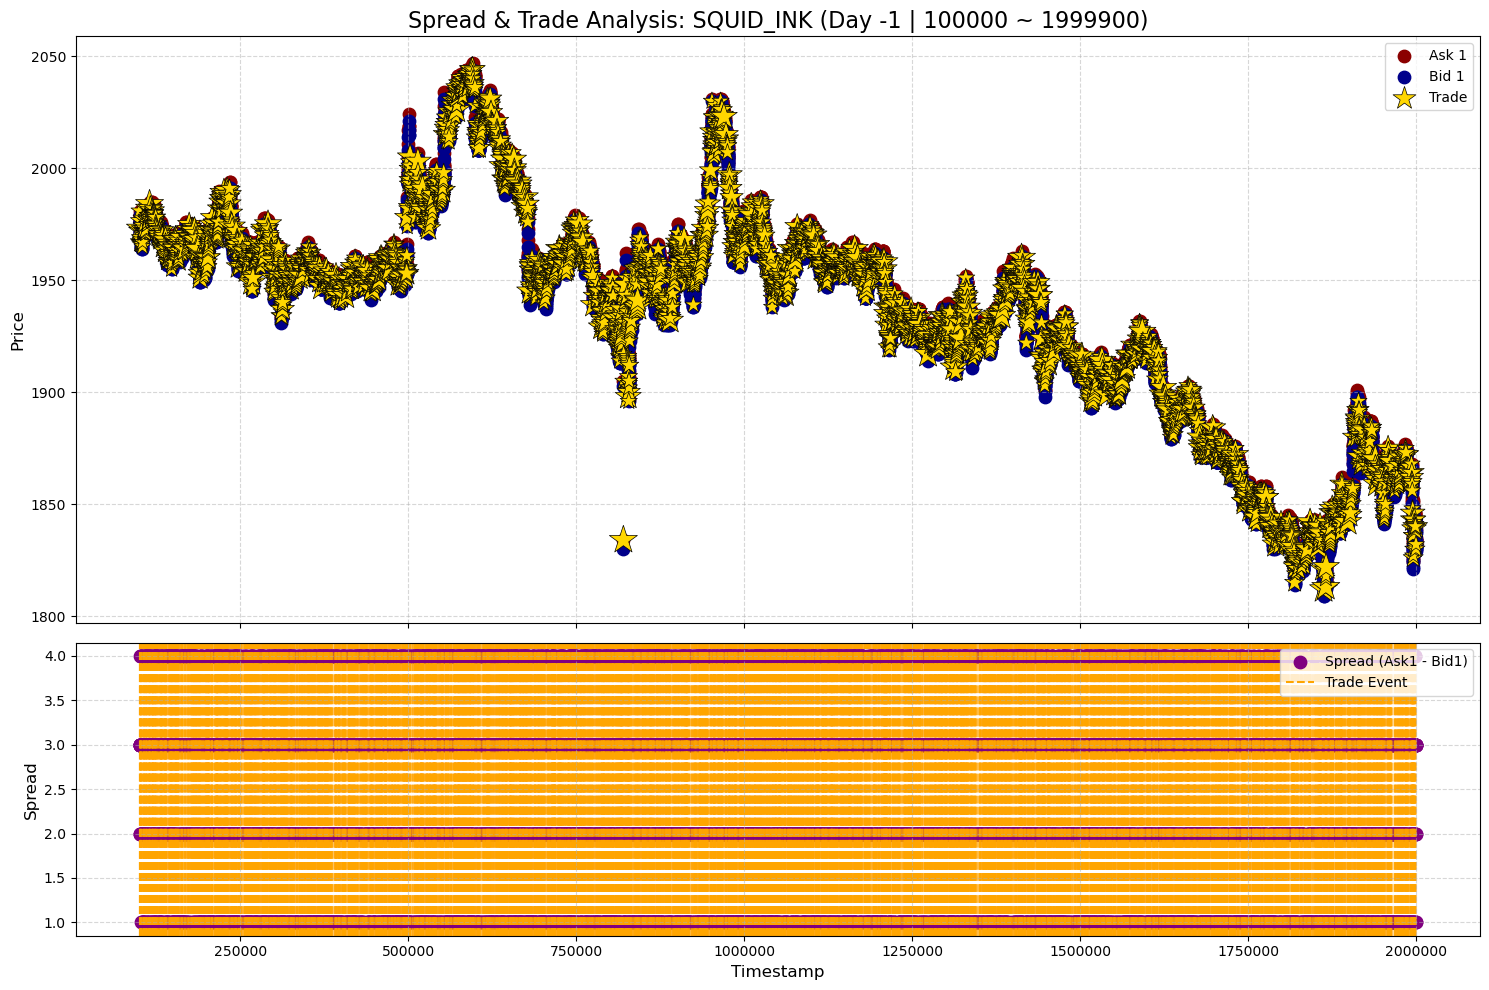

In [188]:
plot_spread_and_trade(book_df, trade_df, target_product='SQUID_INK', start_ts=100000, end_ts=1999900, target_day=-1)

In [279]:
book_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1,1999700,EMERALDS,9992,12,9990,26,NaN,NaN,10008,12,10010,26,NaN,NaN,10000.0,0.0
39996,-1,1999800,EMERALDS,9992,13,9990,20,NaN,NaN,10008,13,10010,20,NaN,NaN,10000.0,0.0
39997,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0
39998,-1,1999900,TOMATOES,4950,10,4949,25,NaN,NaN,4964,10,4965,25,NaN,NaN,4957.0,0.0


(array([6.000e+00, 9.203e+03, 3.194e+03, 0.000e+00, 1.259e+03, 1.795e+03,
        2.158e+03, 0.000e+00, 1.543e+03, 1.361e+03, 1.322e+03, 0.000e+00,
        7.620e+02, 7.560e+02, 2.270e+02, 0.000e+00, 2.090e+02, 1.320e+02,
        1.620e+02, 1.500e+02]),
 array([ 0.  ,  0.75,  1.5 ,  2.25,  3.  ,  3.75,  4.5 ,  5.25,  6.  ,
         6.75,  7.5 ,  8.25,  9.  ,  9.75, 10.5 , 11.25, 12.  , 12.75,
        13.5 , 14.25, 15.  ]),
 <BarContainer object of 20 artists>)

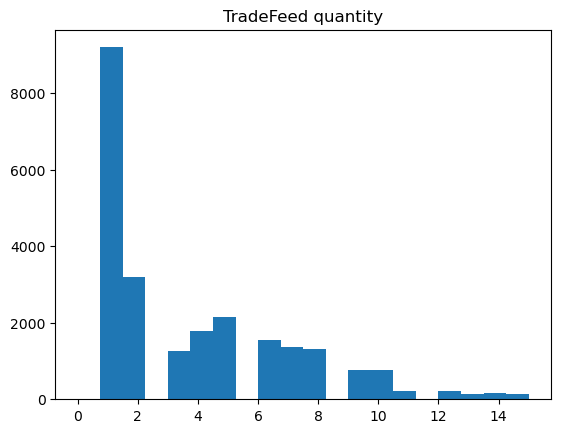

In [106]:
plt.title("TradeFeed quantity")
plt.hist(trade_df['quantity'], bins=20)

In [200]:
book_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,wall_mid,bid_pq_1,ask_pq_1
0,-1,0,CROISSANTS,4304,112,NaN,NaN,NaN,NaN,4305,112,NaN,NaN,NaN,NaN,4304.5,0.0,4304.5,482048,482160
1,-1,0,JAMS,6670,66,6669.0,137.0,NaN,NaN,6671,66,6672.0,137.0,NaN,NaN,6670.5,0.0,6670.5,440220,440286
2,-1,0,SQUID_INK,2005,1,2002.0,31.0,NaN,NaN,2006,31,NaN,NaN,NaN,NaN,2005.5,0.0,2004.0,2005,62186
3,-1,0,PICNIC_BASKET1,59284,20,59283.0,18.0,NaN,NaN,59294,2,59295.0,36.0,NaN,NaN,59289.0,0.0,59289.5,1185680,118588
4,-1,0,PICNIC_BASKET2,30606,20,30605.0,18.0,NaN,NaN,30612,20,30613.0,18.0,NaN,NaN,30609.0,0.0,30609.0,612120,612240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,0,1999900,PICNIC_BASKET1,58716,2,58715.0,34.0,NaN,NaN,58726,18,58727.0,18.0,NaN,NaN,58721.0,0.0,58720.5,117432,1057068
159996,0,1999900,PICNIC_BASKET2,30255,2,30254.0,34.0,NaN,NaN,30260,18,30261.0,18.0,NaN,NaN,30257.5,0.0,30257.0,60510,544680
159997,0,1999900,CROISSANTS,4275,124,NaN,NaN,NaN,NaN,4276,124,NaN,NaN,NaN,NaN,4275.5,0.0,4275.5,530100,530224
159998,0,1999900,JAMS,6541,183,NaN,NaN,NaN,NaN,6543,183,NaN,NaN,NaN,NaN,6542.0,0.0,6542.0,1197003,1197369


In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_post_trade_impact(trade_df, book_df, target_product='SQUID_INK', target_qty=15, interval_ticks=5, over=False):
    # interval_ticks: 타임스탬프 값이 아니라, 오더북 데이터의 '행(row) 개수' 단위입니다. 
    # 예: 5라면 현재 체결 시점 이후 5번째 오더북 업데이트 시점의 가격을 확인.
    
    # 1. order book 세팅
    book = book_df[book_df['product'] == target_product].copy()
    book = book.sort_values('timestamp').reset_index(drop=True)
    book['mid_price'] = (book['bid_price_1'] + book['ask_price_1']) / 2
    
    # 2. 타겟 거래 필터링 (over 파라미터 적용)
    if over:
        # over가 True면 target_qty 초과인 데이터 필터링 (필요시 >= 로 변경 가능)
        trades = trade_df[(trade_df['symbol'] == target_product) & (trade_df['quantity'] >= target_qty)].copy()
        qty_label = f">={target_qty}"
    else:
        # over가 False면 target_qty와 정확히 일치하는 데이터 필터링
        trades = trade_df[(trade_df['symbol'] == target_product) & (trade_df['quantity'] == target_qty)].copy()
        qty_label = f"={target_qty}"

    results = []

    # 3. 거래 분석
    for _, trade in trades.iterrows():
        t = trade['timestamp']
        trade_price = trade['price']

        # 거래 시점(t)과 같거나 가장 가까운 과거의 오더북 인덱스를 찾음
        current_book_idx = book[book['timestamp'] <= t].index.max()
        
        # 만약 찾지 못했거나, 미래 시점 인덱스가 데이터 범위를 벗어나면 패스
        if pd.isna(current_book_idx) or (current_book_idx + interval_ticks) >= len(book):
            continue

        future_book_idx = current_book_idx + interval_ticks
        
        current_mid = book.loc[current_book_idx, 'wall_mid']
        future_mid = book.loc[future_book_idx, 'wall_mid']
        
        ask_1 = book.loc[current_book_idx, 'ask_price_1']
        bid_1 = book.loc[current_book_idx, 'bid_price_1']

        # 거래 방향 추론
        if trade_price >= ask_1:
            direction = 'Buy'
        elif trade_price <= bid_1:
            direction = 'Sell'
        else:
            direction = 'Unknown'

        if direction == 'Unknown':
            continue

        price_change = future_mid - current_mid

        results.append({
            'timestamp': t,
            'direction': direction,
            'price_change': price_change
        })

    res_df = pd.DataFrame(results)

    if res_df.empty:
        print(f"No data found for quantity {qty_label}.")
        return None # Return None if empty to avoid plotting errors

    # --- 시각화 ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # FutureWarning 해결: x를 hue로 지정하고 legend=False 설정
    sns.barplot(data=res_df, x='direction', y='price_change', ax=axes[0],
                hue='direction', palette={'Buy': 'red', 'Sell': 'blue'}, 
                legend=False, errorbar=('ci', 95))
    axes[0].set_title(f'Avg Price Change after {interval_ticks} updates (Qty {qty_label})')
    axes[0].set_ylabel('Mid Price Change (Future - Current)')
    axes[0].axhline(0, color='black', linestyle='--')

    sns.boxplot(data=res_df, x='direction', y='price_change', ax=axes[1],
                hue='direction', palette={'Buy': 'red', 'Sell': 'blue'}, 
                legend=False)
    axes[1].set_title(f'Distribution of Price Change (Qty {qty_label})')
    axes[1].set_ylabel('Mid Price Change')
    axes[1].axhline(0, color='black', linestyle='--')

    plt.suptitle(f'{target_product} - Post Trade Impact Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

    # 터미널 출력
    avg_impact = res_df.groupby('direction')['price_change'].mean().round(2)
    print(f"\n[{target_product} | Qty {qty_label} | Interval={interval_ticks} updates] Average Price Change:")
    print(avg_impact)
    
    return res_df 

# 실행 예시
# result_data = analyze_post_trade_impact(trade_df, book_df, target_product='SQUID_INK', target_qty=15, interval_ticks=5, over=True)

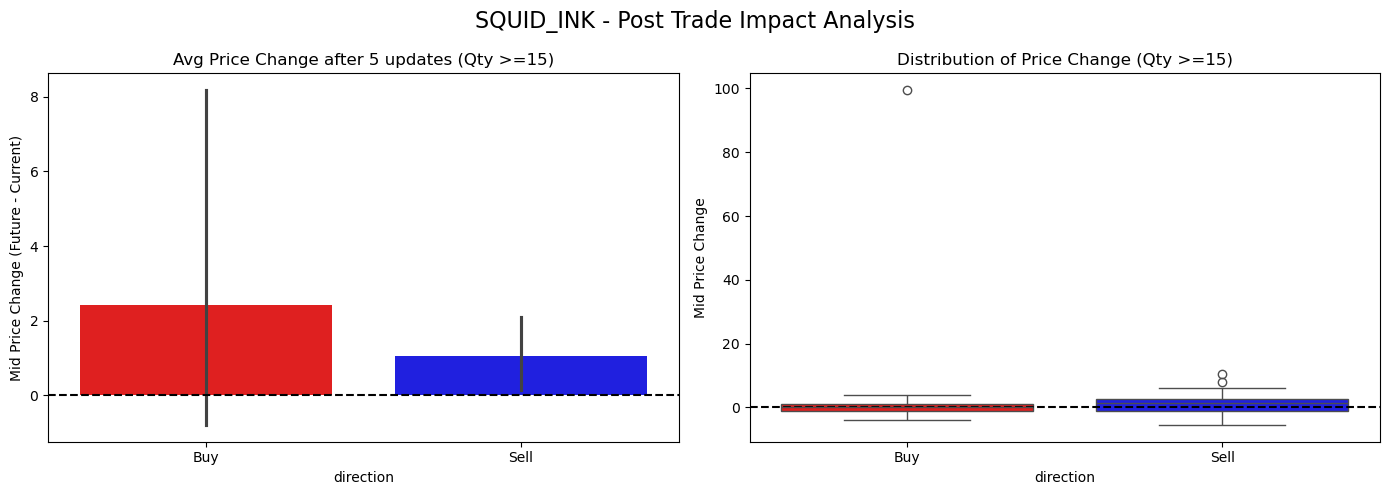


[SQUID_INK | Qty >=15 | Interval=5 updates] Average Price Change:
direction
Buy     2.42
Sell    1.05
Name: price_change, dtype: float64


In [206]:
df = analyze_post_trade_impact(trade_df, book_df, target_product='SQUID_INK', target_qty=15, interval_ticks=5, over=True)

In [216]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_impact_by_quantity(trade_df, book_df, target_product='SQUID_INK', qty_range=range(1, 21), interval_ticks=5):
    """
    qty_range: 분석할 수량(Threshold)의 범위 (예: 1부터 20까지)
    over=True (해당 수량 '이상' 조건)을 기본으로 적용하여 트렌드를 그립니다.
    """
    print("모든 거래의 Price Change를 계산 중입니다. 잠시만 기다려주세요...")
    
    # 1. 오더북 세팅
    book = book_df[book_df['product'] == target_product].copy()
    book = book.sort_values('timestamp').reset_index(drop=True)
    book['mid_price'] = (book['bid_price_1'] + book['ask_price_1']) / 2
    
    # 2. 타겟 상품 거래 필터링
    trades = trade_df[trade_df['symbol'] == target_product].copy()
    
    impact_data = []

    # 3. 모든 거래에 대해 미리 방향과 가격 변화 계산 (연산 최적화)
    for _, trade in trades.iterrows():
        t = trade['timestamp']
        trade_price = trade['price']
        qty = trade['quantity']

        current_book_idx = book[book['timestamp'] <= t].index.max()
        
        if pd.isna(current_book_idx) or (current_book_idx + interval_ticks) >= len(book):
            continue

        future_book_idx = current_book_idx + interval_ticks
        
        current_mid = book.loc[current_book_idx, 'wall_mid']
        future_mid = book.loc[future_book_idx, 'wall_mid']
        
        ask_1 = book.loc[current_book_idx, 'ask_price_1']
        bid_1 = book.loc[current_book_idx, 'bid_price_1']

        # 거래 방향 추론
        if trade_price >= ask_1:
            direction = 'Buy'
        elif trade_price <= bid_1:
            direction = 'Sell'
        else:
            continue # Unknown 패스

        impact_data.append({
            'quantity': qty,
            'direction': direction,
            'price_change': future_mid - current_mid
        })
        
    base_res_df = pd.DataFrame(impact_data)
    
    if base_res_df.empty:
        print("분석할 데이터가 없습니다.")
        return None

    # 4. 지정한 수량(qty_range) 이상인 데이터들을 집계
    plot_data = []
    for q in qty_range:
        # over=True 조건 (지정 수량 이상)
        filtered_df = base_res_df[base_res_df['quantity'] >= q]
        
        if not filtered_df.empty:
            avg_impact = filtered_df.groupby('direction')['price_change'].mean()
            buy_impact = avg_impact.get('Buy', None) # 데이터가 없을 경우 None 처리
            sell_impact = avg_impact.get('Sell', None)
            
            plot_data.append({
                'Threshold_Qty': q,
                'Buy_Impact': buy_impact,
                'Sell_Impact': sell_impact
            })
            
    plot_df = pd.DataFrame(plot_data)

    # 5. 시각화 (선 그래프)
    plt.figure(figsize=(10, 6))
    plt.plot(plot_df['Threshold_Qty'], plot_df['Buy_Impact'], marker='o', color='red', label='Buy (Price Impact)')
    plt.plot(plot_df['Threshold_Qty'], plot_df['Sell_Impact'], marker='o', color='blue', label='Sell (Price Impact)')
    
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'{target_product} - Post Trade Impact Trend by Quantity (Qty >= X)', fontsize=14)
    plt.xlabel('Quantity Threshold (X)')
    plt.ylabel(f'Avg Mid Price Change (after {interval_ticks} updates)')
    plt.xticks(plot_df['Threshold_Qty']) # x축 눈금을 우리가 지정한 수량 단위로 깔끔하게 표시
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return plot_df

# 실행 예시 (1부터 20까지의 수량 변화량을 보고 싶을 때)
# trend_df = plot_impact_by_quantity(trade_df, book_df, target_product='SQUID_INK', qty_range=range(1, 21), interval_ticks=5)

모든 거래의 Price Change를 계산 중입니다. 잠시만 기다려주세요...


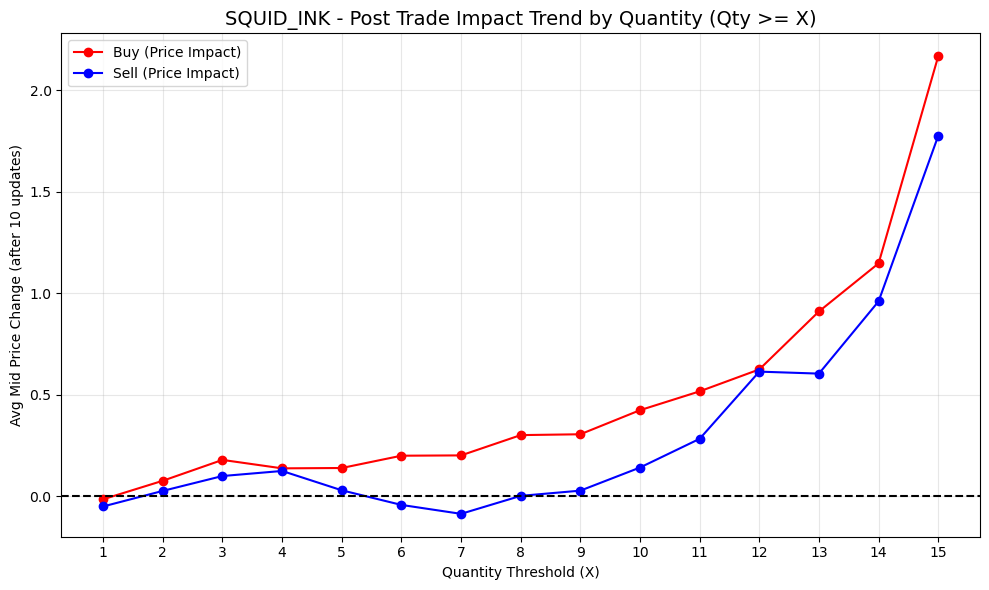

In [218]:
trend_df = plot_impact_by_quantity(trade_df, book_df, target_product='SQUID_INK', qty_range=range(1, 21), interval_ticks=10)

In [182]:
df.groupby('direction')['price_change'].mean().round(2)

direction
Buy     2.11
Sell    1.20
Name: price_change, dtype: float64

In [337]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_book_pressure(book_df, target_product, start_ts, end_ts, target_day=None, window=30):
    """
    위: Mid Price (가격 흐름)
    아래: Smoothed Book Pressure (매수/매도 압력)
    window 파라미터로 이동평균 윈도우 크기를 조절하여 노이즈를 필터링합니다.
    """
    # 1. Book 데이터 필터링
    book_cond = (book_df['product'] == target_product) & \
                (book_df['timestamp'] >= start_ts) & \
                (book_df['timestamp'] <= end_ts)
    
    if target_day is not None and 'day' in book_df.columns:
        book_cond &= (book_df['day'] == target_day)
        
    df = book_df[book_cond].copy()
    df.sort_values('timestamp', inplace=True)

    if df.empty:
        print("해당 구간에 오더북 데이터가 없습니다.")
        return

    # 2. 지표 계산
    # Mid Price 계산 (Ask 1과 Bid 1의 중간값)
    df['mid_price'] = (df['ask_price_1'] + df['bid_price_1']) / 2
    
    # Raw OBI (Book Pressure) 계산: [-1, 1]
    df['obi'] = (df['bid_volume_1'] - df['ask_volume_1']) / (df['bid_volume_1'] + df['ask_volume_1'])
    
    # Smoothed OBI 계산 (단순 이동평균을 사용하여 노이즈 제거)
    df['obi_smoothed'] = df['obi'].rolling(window=window, min_periods=1).mean()

    # 3. 그래프 그리기
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # --- [상단 패널] Mid Price ---
    ax1.plot(df['timestamp'], df['mid_price'], color='black', linewidth=1.5, label='Mid Price')
    
    day_str = f"Day {target_day} | " if target_day is not None else ""
    ax1.set_title(f"Price & Book Pressure Analysis: {target_product} ({day_str}Rolling Window: {window})", fontsize=16)
    ax1.set_ylabel("Mid Price", fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- [하단 패널] Smoothed Book Pressure ---
    # 중심선(0) 긋기
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
    
    # OBI 선 그리기
    ax2.plot(df['timestamp'], df['obi_smoothed'], color='purple', linewidth=1.5, label=f'Smoothed OBI (Window={window})')
    
    # 시각적 직관성을 위해 0보다 크면 파란색(매수 압력), 0보다 작으면 빨간색(매도 압력)으로 칠하기
    ax2.fill_between(df['timestamp'], 0, df['obi_smoothed'], where=(df['obi_smoothed'] >= 0), color='blue', alpha=0.3, interpolate=True)
    ax2.fill_between(df['timestamp'], 0, df['obi_smoothed'], where=(df['obi_smoothed'] < 0), color='red', alpha=0.3, interpolate=True)

    ax2.set_xlabel("Timestamp", fontsize=12)
    ax2.set_ylabel("Book Pressure (OBI)", fontsize=12)
    ax2.set_ylim(-0.3, 0.3) # OBI는 항상 -1과 1 사이
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.ticklabel_format(style='plain', axis='x')

    plt.tight_layout()
    plt.show()

# 실행 예시: (전체 구간을 보려면 아래처럼 실행)
# plot_book_pressure(book_df, target_product='TOMATOES', start_ts=10000, end_ts=1999900, target_day=-1, window=500)

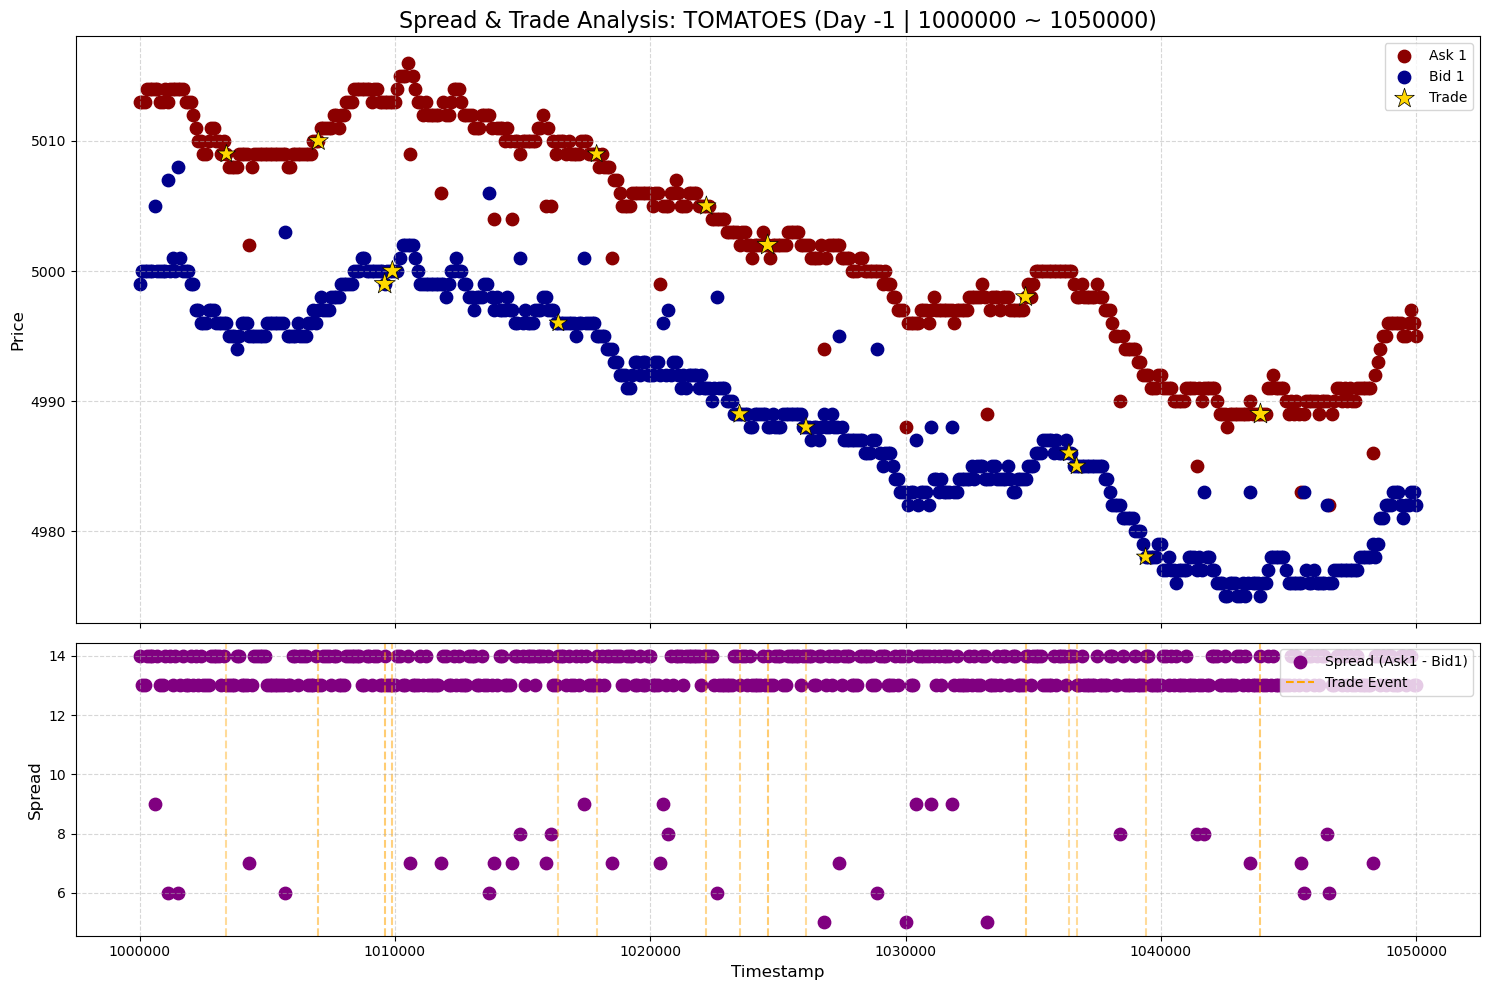

In [295]:
plot_spread_and_trade(book_df, trade_df, target_product='TOMATOES', start_ts=1000000, end_ts=1050000, target_day=-1)

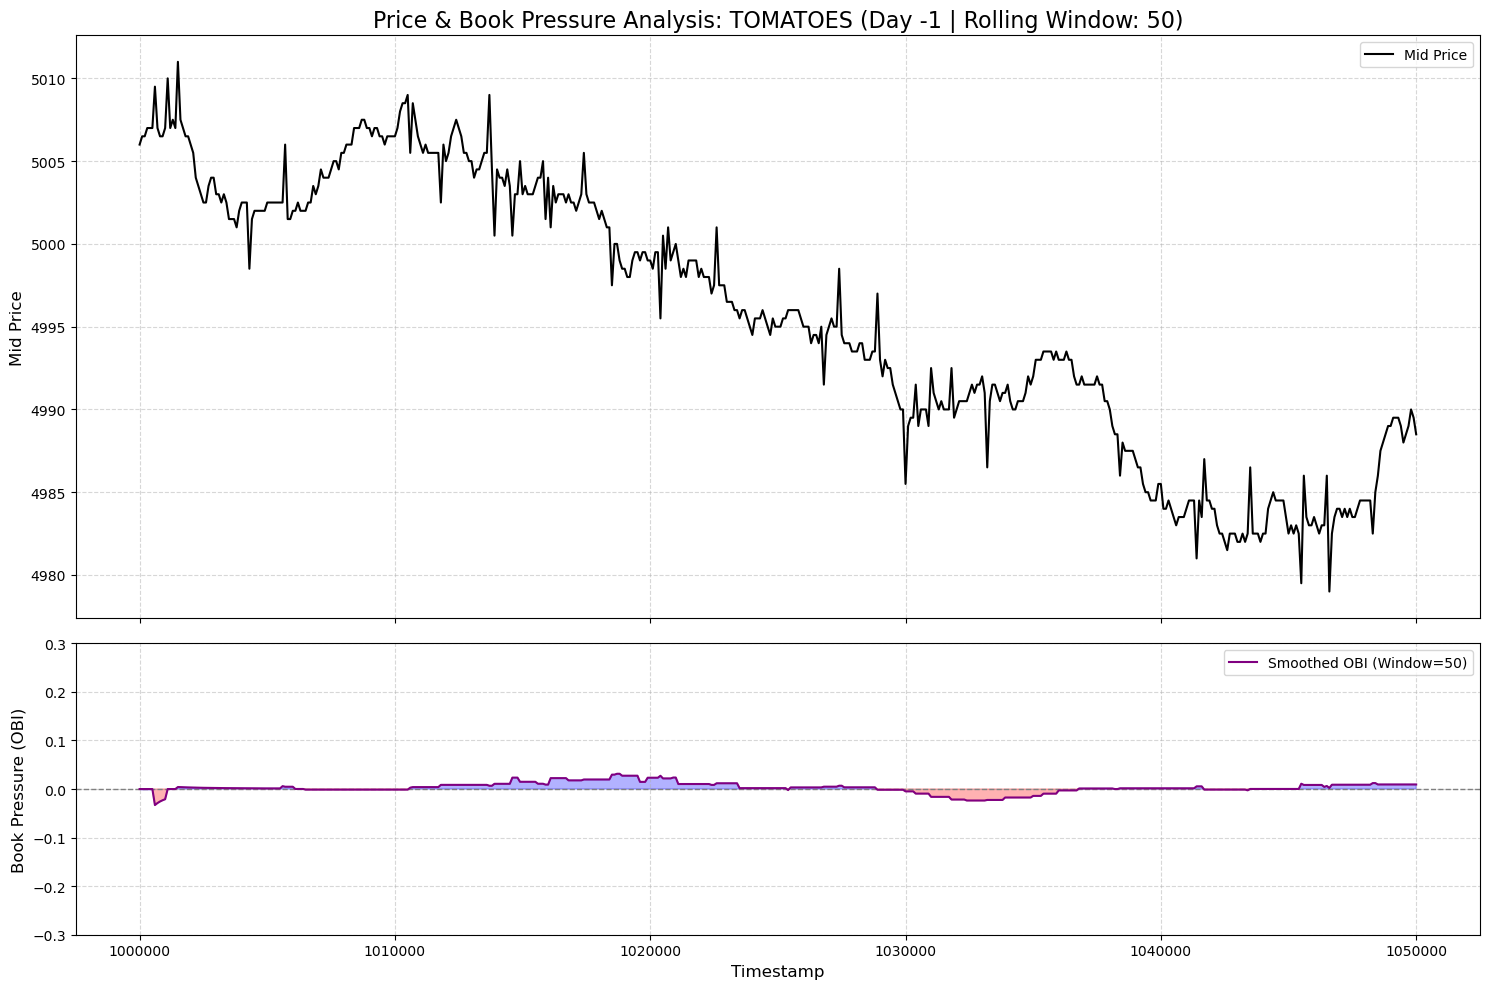

In [355]:
plot_book_pressure(book_df, target_product='TOMATOES', start_ts=1000000, end_ts=1050000, target_day=-1, window=50)

In [ ]:
class LeaningTrader(ProductTrader):
    def __init__(self, state, prints, new_trader_data):
        super().__init__(INK_SYMBOL, state, prints, new_trader_data)
        
        self.window = int(os.getenv('LEANING_WINDOW', 200))
        self.k = float(os.getenv('LEANING_K', 0.2))
        self.skew_factor = float(os.getenv('LEANING_SKEW', 1.2))
        self.cooldown_ticks = int(os.getenv('LEANING_COOL', 100))
        # 기본 볼린저 밴드 파라미터
        print(self.window, self.k, self.skew_factor, self.cooldown_ticks)

    def get_orders(self):
        if self.wall_mid is None:
            return {}

        # 1. 상태 데이터 로드
        history = self.last_traderData.get(f'{self.name}_HIST', [])
        last_trade_ts = self.last_traderData.get(f'{self.name}_LAST_TRADE', -9999)
        
        history.append(self.wall_mid)
        if len(history) > self.window:
            history.pop(0)
            
        self.new_trader_data[f'{self.name}_HIST'] = history
        self.new_trader_data[f'{self.name}_LAST_TRADE'] = last_trade_ts

        if len(history) < self.window:
            return {self.name: self.orders}

        # 2. 기본 통계량 계산
        sma = np.mean(history)
        std = np.std(history) if np.std(history) > 0 else 1.0

        # 3. Leaning (Continuous Inventory Skew) 적용
        pos_ratio = self.initial_position / self.position_limit 
        skew = pos_ratio * self.skew_factor * std 
        
        adj_sma = sma - skew
        adj_upper = sma + (self.k * std) - skew
        adj_lower = sma - (self.k * std) - skew

        # 4. Order Cooltime 체크
        is_cooling_down = self.state.timestamp < (last_trade_ts + self.cooldown_ticks)

        # 5. 주문 로직
        trade_executed = False

        # 신규 진입 (쿨타임이 아닐 때만)
        if not is_cooling_down:
            if self.wall_mid < adj_lower and self.max_allowed_buy_volume > 0:
                deviation = adj_lower - self.wall_mid
                buy_qty = min(self.max_allowed_buy_volume, int(deviation * 2) + 1)
                self.bid(self.bid_wall, buy_qty, logging=False)
                trade_executed = True

            elif self.wall_mid > adj_upper and self.max_allowed_sell_volume > 0:
                deviation = self.wall_mid - adj_upper
                sell_qty = min(self.max_allowed_sell_volume, int(deviation * 2) + 1)
                self.ask(self.ask_wall, sell_qty, logging=False)
                trade_executed = True

        # 익절 (쿨타임 무시)
        if self.initial_position > 0 and self.wall_mid >= adj_sma:
            self.ask(self.ask_wall, self.initial_position, logging=False)
            trade_executed = True
            
        elif self.initial_position < 0 and self.wall_mid <= adj_sma:
            self.bid(self.bid_wall, abs(self.initial_position), logging=False)
            trade_executed = True

        if trade_executed:
            self.new_trader_data[f'{self.name}_LAST_TRADE'] = self.state.timestamp

        return {self.name: self.orders}


"""
WINDOWS = [30, 50, 100, 200]
KS = [1.0, 1.5, 2.0, 0.5, 0.2]
SKEW_FACTORS = [0.5, 0.8, 1.0, 1.2, 1.5]
COOLDOWNS = [100, 500, 1000]
"""

[TOMATOES] Book Pressure와 Future Price Change의 상관계수: 0.3258


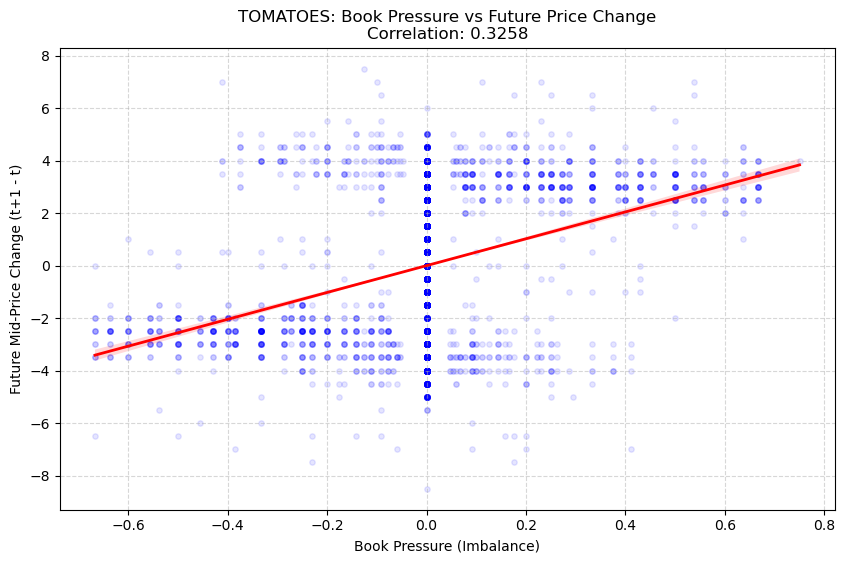

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pressure_vs_price_change(df: pd.DataFrame, target_product: str):
    # 1. 특정 상품 필터링 및 시간순 정렬
    prod_df = df[df['product'] == target_product].copy()
    prod_df = prod_df.sort_values(by=['day', 'timestamp']).reset_index(drop=True)

    # 2. Mid Price 계산: (최우선 매수호가 + 최우선 매도호가) / 2
    prod_df['mid_price'] = (prod_df['bid_price_1'] + prod_df['ask_price_1']) / 2

    # 3. Book Pressure (Order Book Imbalance) 계산
    # 레벨 1 호가 기준: (매수잔량 - 매도잔량) / (매수잔량 + 매도잔량)
    # 1에 가까울수록 매수세가 강함, -1에 가까울수록 매도세가 강함
    prod_df['book_pressure'] = (prod_df['bid_volume_1'] - prod_df['ask_volume_1']) / \
                               (prod_df['bid_volume_1'] + prod_df['ask_volume_1'])

    # 4. 미래 가격 변화량 (Future Price Change) 계산
    # 다음 틱(t+1)의 Mid Price에서 현재 틱(t)의 Mid Price를 뺌
    prod_df['future_price_change'] = prod_df['mid_price'].shift(-1) - prod_df['mid_price']

    # 결측치 제거 (shift로 인해 마지막 행에 NaN이 발생함)
    prod_df = prod_df.dropna(subset=['book_pressure', 'future_price_change'])

    # 5. 상관계수(Correlation) 계산
    correlation = prod_df['book_pressure'].corr(prod_df['future_price_change'])
    print(f"[{target_product}] Book Pressure와 Future Price Change의 상관계수: {correlation:.4f}")

    # 6. Scatter Plot (산점도) 시각화
    plt.figure(figsize=(10, 6))
    
    # seaborn의 regplot을 사용하면 산점도 위에 선형 회귀선(트렌드 라인)을 그어주어 직관적입니다.
    sns.regplot(
        data=prod_df, 
        x='book_pressure', 
        y='future_price_change', 
        scatter_kws={'alpha': 0.1, 's': 15, 'color': 'blue'}, # 데이터가 많으므로 투명도(alpha) 조절
        line_kws={'color': 'red', 'linewidth': 2}
    )
    
    plt.title(f"{target_product}: Book Pressure vs Future Price Change\nCorrelation: {correlation:.4f}")
    plt.xlabel("Book Pressure (Imbalance)")
    plt.ylabel("Future Mid-Price Change (t+1 - t)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 사용 예시 (앞서 로드한 book_df를 넣고 실행하시면 됩니다)
plot_pressure_vs_price_change(book_df, target_product='TOMATOES')